In [51]:
from functions.clustering_functions import clustering_optimal_number, modularity_density
from functions.plots import plot_PDens_Q
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic_fit_matrix, ask_yes_no
from functions.cosmograph_functions import visualize_graph_amlsim

In [52]:
user_input = ask_yes_no("\nDo you want to load data?")



In [53]:
results_squic = {}

name = 'AMLSIM'

if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)

else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit_matrix(Y_norm, knn_matrix, results_squic, name, dimension)

else:
    results_squic, squic_method, save = run_squic_fit(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
            0           1           2           3           4           5  \
0  184.440000  184.440000  184.440000  184.440000  184.440000  184.440000   
1    0.153330    0.153330    0.153330    0.153330    0.153330    0.153330   
2    0.182678    0.182678    0.182678    0.182678    0.182678    0.182678   
3    0.214058    0.214058    0.214058    0.214058    0.214058    0.214058   
4    0.168818    0.168818    0.168818    0.168818    0.168818    0.168818   

            6           7           8           9  ...         190  \
0  184.440000  184.440000  184.440000  184.440000  ...  184.440000   
1    0.000000    0.000000    0.000000    0.000000  ...   -3.066594   
2    0.182678    0.182678    0.182678    0.182678  ...   -2.739970   
3    0.214058    0.214058    0.214058    0.214058  ...   -2.891597   
4    0.168818    0.168818    0.168818    0.168818  ...   -3.207538   

          191         192         193         194         195         196  \
0  184.440000  184.4

Is G connected for l=0.999999? False
# CC : 141
Is G connected for l=0.999995? False
# CC : 135
Attempt 1 failed: ARPACK error -1: No convergence (1001 iterations, 11/13 eigenvectors converged)
Is G connected for l=0.99999? False
# CC : 134
Attempt 1 failed: ARPACK error -1: No convergence (1001 iterations, 7/13 eigenvectors converged)
For rho 0.999999:
    Louvain: PDensity = 0.02, Int Density = 0.23, Q = 0.88, nCluster = 182, nIsolated  = 119
    Leiden: PDensity = 0.03, Int Density = 0.21, Q = 0.9, nCluster = 204, nIsolated  = 119
    DBSCAN: PDensity = 0.01, Int Density = 0.07, Q = 0.04, nCluster = 642, nIsolated  = 585
    Spectral: PDensity = 0.0, Int Density = 0.28, Q = 0.01, nCluster = 6, nIsolated  = 0
For rho 0.999995:
    Louvain: PDensity = 0.02, Int Density = 0.24, Q = 0.89, nCluster = 176, nIsolated  = 115
    Leiden: PDensity = 0.03, Int Density = 0.21, Q = 0.9, nCluster = 199, nIsolated  = 115
    DBSCAN: PDensity = 0.01, Int Density = 0.07, Q = 0.04, nCluster = 634, nI

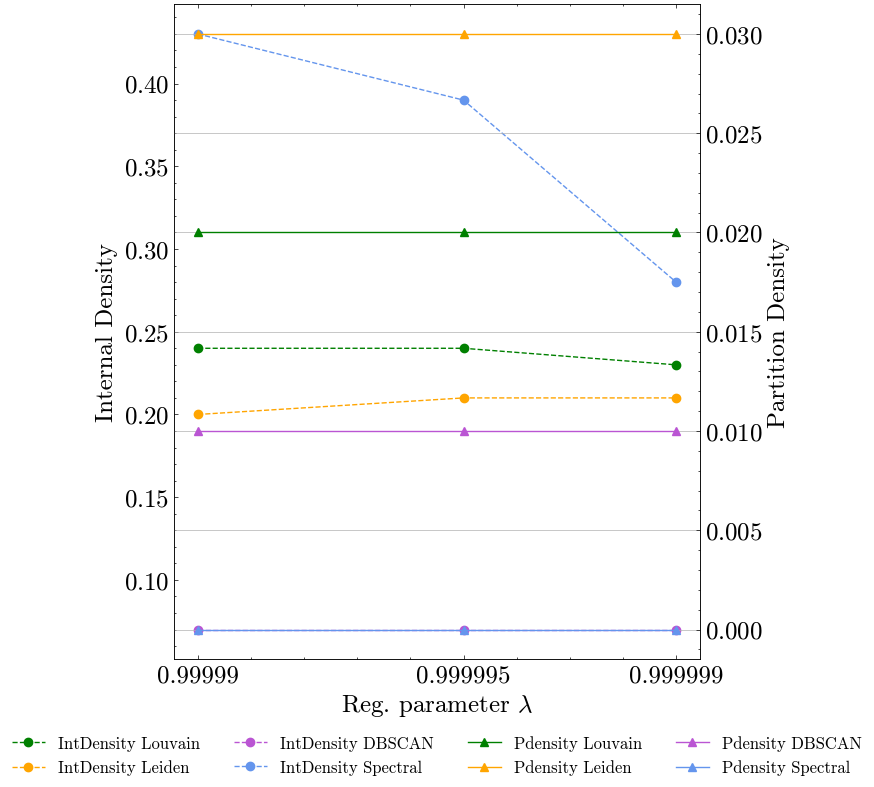

In [54]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save, metric='int_density')

In [55]:
lambda_graph = {
    '100': 0.2,
    '1K': 0.9999,
    '10K': 0.999999,
    '100K': 0.99999999
}

In [56]:
graph = visualize_graph_amlsim(results_squic, squic_method, dict_cluster, account_prop, export=lambda_graph.get(dimension))

Exported for Cosmograph WebApp: cosmograph_export/AMLSIM_0.999999_Louvain_edges.csv and _nodes.csv
Exported for Cosmograph WebApp: cosmograph_export/AMLSIM_0.999999_Spectral_edges.csv and _nodes.csv
Exported for Cosmograph WebApp: cosmograph_export/AMLSIM_0.999999_DBSCAN_edges.csv and _nodes.csv
Exported for Cosmograph WebApp: cosmograph_export/AMLSIM_0.999999_Leiden_edges.csv and _nodes.csv


In [57]:
graph[lambda_graph.get(dimension)]['Spectral']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [58]:
graph[lambda_graph.get(dimension)]['Leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [59]:
graph[lambda_graph.get(dimension)]['Louvain']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [60]:
graph[lambda_graph.get(dimension)]['DBSCAN']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…